In [33]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import onnxruntime as ort

from numpy.lib.stride_tricks import sliding_window_view
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm

In [34]:
seq_len = 50
pred_distance = 0

model = ort.InferenceSession(f"outputs/checkpoints/model_seq_{seq_len}_pred_{pred_distance}_75m.onnx")

In [35]:
file_name_list = ['data20251125-095900.csv',
                  'data20251125-101823.csv',
                  'data20251125-102237.csv']


data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data_list.append(data)

data = pd.concat(data_list, axis=0)

data_sorted = data.copy()
data_sorted = data_sorted[data_sorted['boom_length(m)'] > 1]
data_sorted.reset_index(drop=True, inplace=True)

load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']

for load_cell_name in load_cell_name_list:
    load = data_sorted[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=5), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*4)
    data_sorted[load_cell_name] = filtered_load

In [36]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

load_sum = data_sorted[load_cell_name_list].sum(axis=1)
front = (data_sorted[load_cell_name_list[0]]+data_sorted[load_cell_name_list[3]])/load_sum
rear = (data_sorted[load_cell_name_list[2]]+data_sorted[load_cell_name_list[5]])/load_sum

load_ratio = np.abs(front - rear)
roll_over_state = (load_ratio < 0.35)*1
data_sorted['roll_over_state'] = roll_over_state

In [37]:
feature_name_list = ['boom_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)']
target_name = 'roll_over_state'

dataset_arr = data_sorted[feature_name_list+[target_name]].to_numpy()

feature = dataset_arr[:, 0:len(feature_name_list)]
target = dataset_arr[:, len(feature_name_list)]

input_buf = np.zeros(shape=(1, seq_len, len(feature_name_list)), dtype=np.float32)
pred_list = []

for input_sig in tqdm(feature):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = input_sig

    pred_list.append(np.square(model.run(output_names=None, input_feed={'input': input_buf})).item())

pred_arr = np.array(pred_list)

  0%|          | 0/13196 [00:00<?, ?it/s]

In [38]:
target_string = []

for sig in target:
    if sig == 1:
        target_string.append('Unsafe')
    else:
        target_string.append('Safe')

result_df = pd.concat([pd.DataFrame(pred_arr, columns=['prediction']),
                       pd.DataFrame(target_string, columns=['target'])], axis=1)

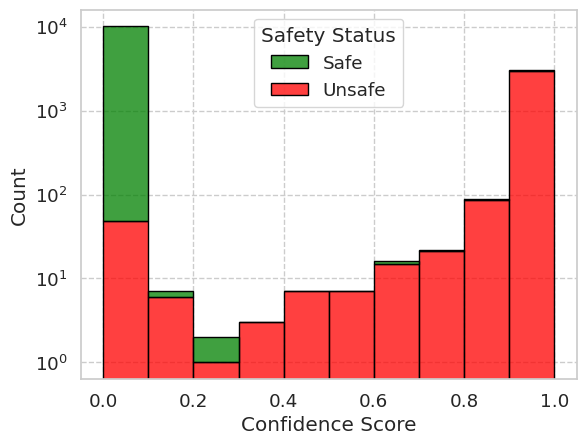

In [39]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'Unsafe': 'red', 'Safe': 'green'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('Confidence Score')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

Best Threshold: 0.010
Best F1 Score: 0.9910


Text(0, 0.5, 'Score')

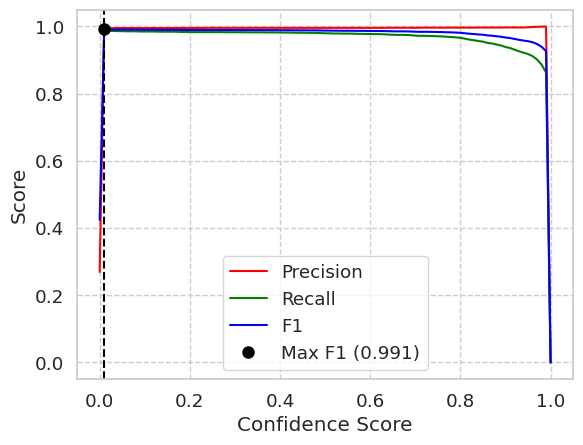

In [40]:
thr_val_arr = np.arange(0.0, 1.01, 0.01)

precision_arr = []
recall_arr = []
f1_arr = []

for thr_val in thr_val_arr:
    pred_binary = np.where(pred_arr > thr_val, 1, 0)
    precision = precision_score(target, pred_binary, zero_division=0)
    recall = recall_score(target, pred_binary, zero_division=0)
    f1 = f1_score(target, pred_binary, zero_division=0)

    precision_arr.append(precision)
    recall_arr.append(recall)
    f1_arr.append(f1)

precision_arr = np.array(precision_arr)
recall_arr = np.array(recall_arr)
f1_arr = np.array(f1_arr)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=thr_val_arr, y=precision_arr, color='red', label='Precision')
sns.lineplot(x=thr_val_arr, y=recall_arr, color='green', label='Recall')
sns.lineplot(x=thr_val_arr, y=f1_arr, color='blue', label='F1')

best_f1_index = np.argmax(f1_arr)

best_threshold = thr_val_arr[best_f1_index]
best_f1_score = f1_arr[best_f1_index]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1_score:.4f}")

plt.axvline(x=best_threshold, color='black', linestyle='--')

plt.plot(best_threshold, best_f1_score, 'o', color='black', markersize=8,
         markeredgecolor='black', label=f'Max F1 ({best_f1_score:.3f})')

plt.legend()

plt.xlabel('Confidence Score')
plt.ylabel('Score')

([<matplotlib.axis.YTick at 0x714438d06b10>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

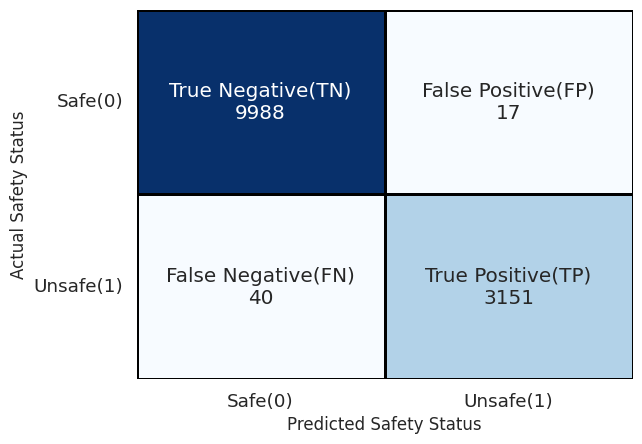

In [41]:
pred_binary = np.where(pred_arr > best_threshold, 1, 0)

cm = confusion_matrix(target, pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

In [42]:
print(precision_score(target, pred_binary))
print(recall_score(target, pred_binary))
print(f1_score(target, pred_binary))
print(accuracy_score(target, pred_binary))

0.9946338383838383
0.9874647445941711
0.9910363264664256
0.9956805092452258


In [43]:
file_name_list = [file_name_list[0]]

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data_list.append(data)

data = pd.concat(data_list, axis=0)

data_sorted = data.copy()
data_sorted = data_sorted[data_sorted['boom_length(m)'] > 1]
data_sorted.reset_index(drop=True, inplace=True)

load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']

for load_cell_name in load_cell_name_list:
    load = data_sorted[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=5), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*4)
    data_sorted[load_cell_name] = filtered_load

Text(0.5, 0, 'Time(sec)')

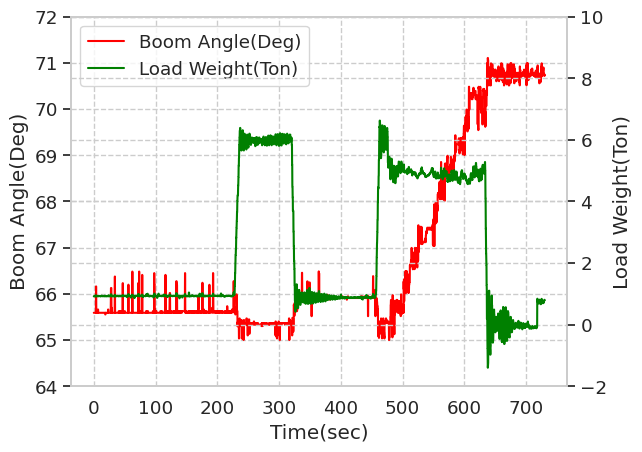

In [44]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(data=data_sorted, x='time(sec)', y='boom_angle(deg)', color='red', label='Boom Angle(Deg)', ax=ax1)
sns.lineplot(data=data_sorted, x='time(sec)', y='load_weight(ton)', color='green', label='Load Weight(Ton)', ax=ax2)


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='upper left')
ax2.get_legend().remove() if ax2.get_legend() else None

ax1.set_ylabel(labels_1[0])
ax1.set_ylim(64, 72)

ax2.set_ylabel(labels_2[0])
ax2.set_ylim(-2, 10)

ax1.set_xlabel('Time(sec)')

Text(0, 0.5, 'Load(Ton)')

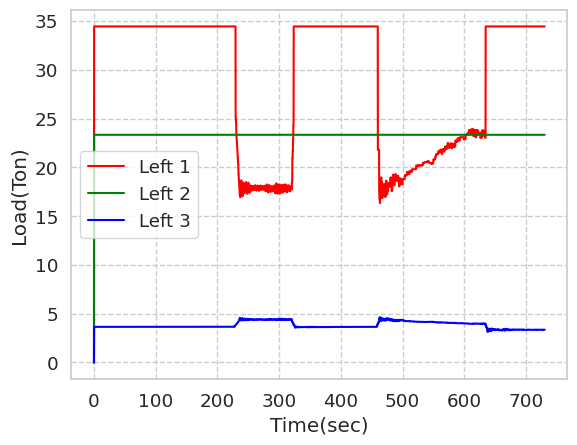

In [45]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3']
legend_name_list = ['Left 1', 'Left 2', 'Left 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

#plt.ylim(0, 40)
plt.ylabel('Load(Ton)')

Text(0, 0.5, 'Load(Ton)')

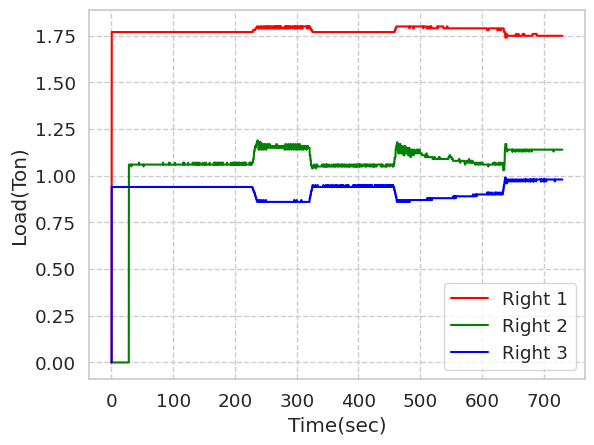

In [46]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
legend_name_list = ['Right 1', 'Right 2', 'Right 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

#plt.ylim(0, 40)
plt.ylabel('Load(Ton)')

<Axes: xlabel='time(sec)', ylabel='None'>

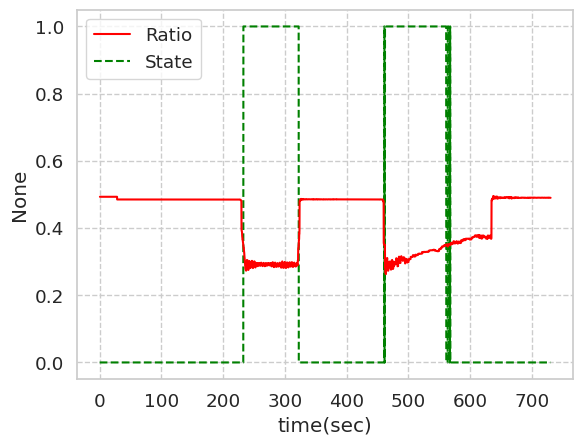

In [47]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

load_sum = data_sorted[load_cell_name_list].sum(axis=1)
front = (data_sorted[load_cell_name_list[0]]+data_sorted[load_cell_name_list[3]])/load_sum
rear = (data_sorted[load_cell_name_list[2]]+data_sorted[load_cell_name_list[5]])/load_sum

load_ratio = np.abs(front - rear)
roll_over_state = (load_ratio < 0.35)*1
data_sorted['roll_over_state'] = roll_over_state

sns.lineplot(x=data_sorted['time(sec)'], y=load_ratio, color='red', label='Ratio', zorder=3)
sns.lineplot(x=data_sorted['time(sec)'], y=roll_over_state, color='green', linestyle='--', label='State')

In [48]:
feature_name_list = ['boom_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)']
target_name = 'roll_over_state'

dataset_arr = data_sorted[feature_name_list+[target_name]].to_numpy()

feature = dataset_arr[:, 0:len(feature_name_list)]
target = dataset_arr[:, len(feature_name_list)]

input_buf = np.zeros(shape=(1, seq_len, len(feature_name_list)), dtype=np.float32)
pred_list = []

for input_sig in tqdm(feature):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = input_sig

    pred_list.append(np.square(model.run(output_names=None, input_feed={'input': input_buf})).item())

pred_arr = np.array(pred_list)

  0%|          | 0/7215 [00:00<?, ?it/s]

In [49]:
target_string = []

for sig in target:
    if sig == 1:
        target_string.append('Unsafe')
    else:
        target_string.append('Safe')

result_df = pd.concat([pd.DataFrame(pred_arr, columns=['prediction']),
                       pd.DataFrame(target_string, columns=['target'])], axis=1)

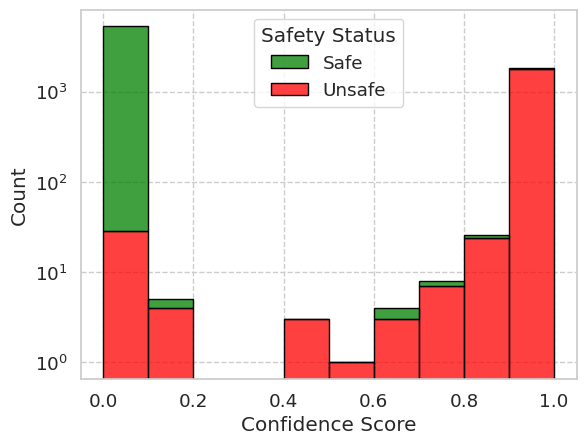

In [50]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'Unsafe': 'red', 'Safe': 'green'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('Confidence Score')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

([<matplotlib.axis.YTick at 0x7144307a0210>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

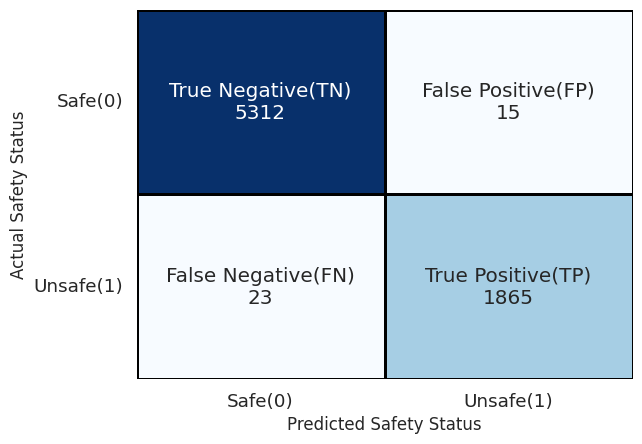

In [51]:
pred_binary = np.where(pred_arr > best_threshold, 1, 0)

cm = confusion_matrix(target, pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

In [52]:
print(precision_score(target, pred_binary))
print(recall_score(target, pred_binary))
print(f1_score(target, pred_binary))
print(accuracy_score(target, pred_binary))

0.9920212765957447
0.9878177966101694
0.9899150743099787
0.9947331947331948
